In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", None, "display.max_columns", None)

**Video Game Sales Analysis  
**Name:** Khoa Le  
**Course:** CMPS 6790  
**Milestone 1**
**GitHub Repository: https://github.com/khoaboa1/khoaboa1.github.io**
**Github Webpage: https://khoaboa1.github.io/Milestone1.html**

In [28]:
df = pd.read_csv("data/vgsales.csv")

print("Before cleaning:")
df.info()
df.isnull().sum()

Before cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

## Project Goal
For this project, I will be working individually to investigate patterns in the  global video game industry using the Video Game Sales dataset sourced from Kaggle, originally compiled by VGChartz. This dataset contains sales records for over 16,500  video games released between 1980 and 2020. Each row represents a single game release and includes the game's title, platform, release year, genre, publisher, and sales figures broken down by region — North America, Europe, Japan — as well as a global total, all measured in millions of units sold.

I choose this dataset first of all because I like video games. Futhermore, video game industry represents one of the fastest-growing entertainment sectors of the past four decades and the data provides a rare opportunity to see the development of the industry time by time.

There are several questions I hope to answer with this data. First, which gaming platforms have dominated global sales, and how has platform dominance shifted across different decades. For instance, from the PC-dominated 1990s, when DOS and CD-ROM games defined mainstream gaming, through the console era of the 2000s led by PlayStation and Xbox. Second, how do genre preferences differ across the three major regional markets, and are certain genres disproportionately popular in one region versus another?

## Project Plan
With questions I provided, the Video Game Sales dataset is well-positioned to answer this question because it contains sales figures from 1980 to 2020. This multi-dimensional structure allows for analysis across time, geography, and industry category simultaneously.
Specifically, the data can be used to explore several angles of commercial success:

**Platform dominance over time:** By grouping sales data by platform and decade, we can trace how dominant platforms have shifted — from early PC and NES dominance in the 1980s and 1990s, through the PlayStation and Xbox era of the 2000s, to modern platforms. This directly addresses the question of what hardware environment has historically produced the most successful titles.

**Genre preferences by region:** The dataset's regional breakdown across North America, Europe, and Japan allows for direct comparison of genre preferences across markets. If certain genres consistently outperform in specific regions, this would suggest that cultural factors play a meaningful role in commercial success — a finding with real implications for how publishers target their releases.


## Colaboration Plan

This project is completed individually. All work is managed through a personal GitHub  repository with the project site published via GitHub Pages. Development is done locally in JupyterLab, running with Docker Containers, with commits pushed to the repository after each working session.


## ETL (Extraction, Transform, and Load)

The dataset I uses was downloaded from Kaggle and loaded into pandas as a CSV file.  This dataset shows the Rank, Year, Name, Platform, Genre, Publisher, and the sale from other continents. From Kaggle, we see dataframe contained 16598 rows and 11 columns, but several roews had null values in the Year and Publisher columns. Since Year is essential for any time-based analysis, we will drop all rows have the issue of missing a year. The `Year` column was converted from float to integer for cleaner display and grouping. The resulting tidy dataset covers games released between 1980 and 2020, with one game per row and each variable stored in its own clearly labeled column — consistent with the principles of tidy data.

In [32]:
df = df.dropna(subset=['Year', 'Publisher'])

# Convert Year from float to int
df['Year'] = df['Year'].astype(int)

# Display tidy result
display(df.head())
display(df.dtypes)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

### Interesting Statistic

One of the first questions we can ask of this dataset is: which genre has dominated global video game sales over the past four decades? To investigate, we can look at the top-selling games and see if any pattern emerges.

In [30]:
top_games = df.sort_values('Global_Sales', ascending=False)
display(top_games.head(10))

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Looking at the top 10 best-selling games of all time in this dataset, a few patterns immediately stand out. First, Nintendo dominates — every single game in the top 10 is published by Nintendo. Second, Sports is the leading genre at the top, with Wii Sports alone selling 82.74 million units globally, making it the best-selling game in the entire dataset. This is largely driven by the Wii console era (2006–2009), where motion-controlled sports games reached audiences far beyond traditional gamers. However, to determine which genre is truly dominant across the entire dataset — not just the top 10 — we need to look at total sales aggregated by genre, which we will explore in the visualization below.

### Which Genre Has Dominated Global Video Game Sales?
While the top 10 individual games are dominated by Nintendo's Sports and Platform titles, we want to see the full picture across all 16,291 games. The chart below aggregates total global sales by genre to answer this question definitively.

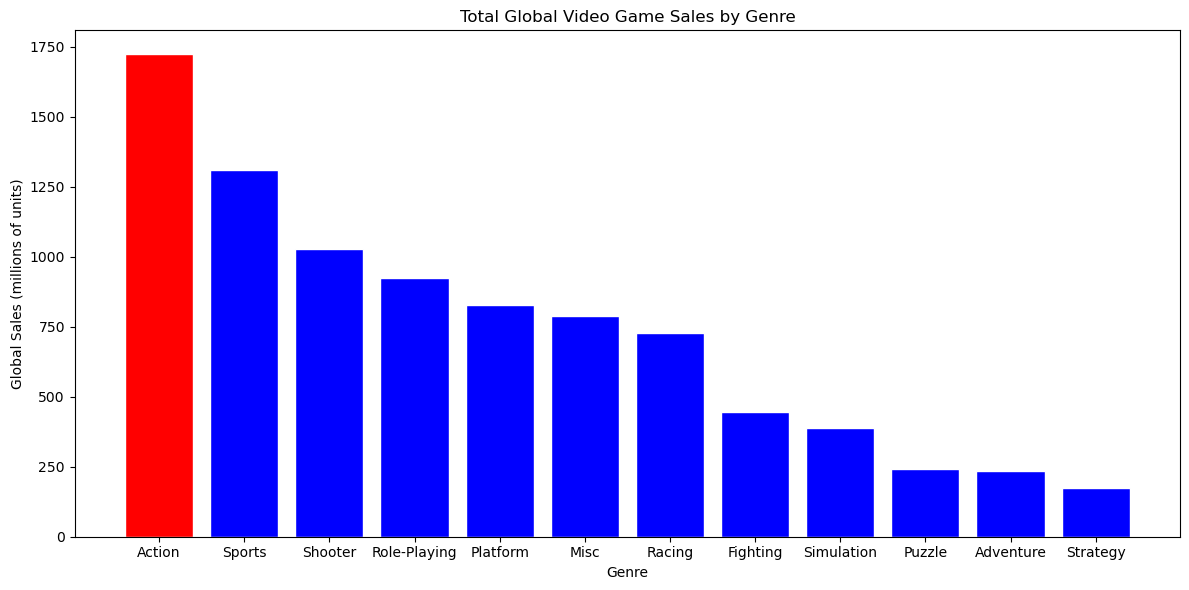

In [31]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red'] + ['blue'] * (len(genre_sales) - 1)

bars = ax.bar(genre_sales.index, genre_sales.values, color=colors, edgecolor='white')

ax.set_title('Total Global Video Game Sales by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Global Sales (millions of units)')

plt.tight_layout()
plt.show()